In [3]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 


In [4]:
df = pd.read_csv('/Users/anuragpanchal/Documents/MachineLearning/TimeSeries/AirPassengers.csv')

In [5]:
df

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [6]:
# we need to predict future airline passenger using past data 


In [7]:
df.isna().sum()

Month          0
#Passengers    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [10]:
df['Month'] = pd.to_datetime(df['Month'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [12]:
df.set_index('Month',inplace=True)

In [13]:
df

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


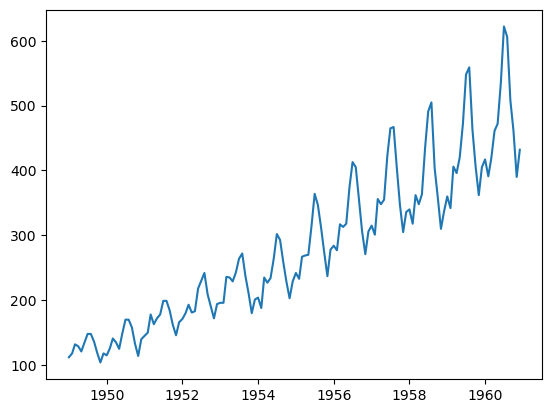

In [14]:
#component of time seris 

plt.plot(df['#Passengers'])

1.Trend -> increasing Trend 
2.Seasonality -> Yes 
-There are irregular deviation as the residual representing random noise,or model imperfection 

In [15]:
#seasonal decomposition to check the presenece of components of the time series 
from statsmodels.tsa.seasonal import seasonal_decompose

In [16]:
seasonal_decompose =seasonal_decompose(df['#Passengers'])

Figure(640x480)


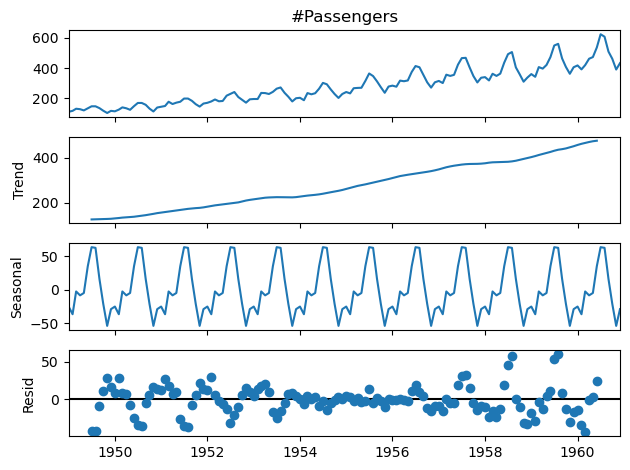

In [ ]:
print(seasonal_decompose.plot())

In [18]:
# check weather data is stationary or not 

from statsmodels.tsa.stattools import adfuller

In [19]:
ad = adfuller(df['#Passengers'])

In [20]:
ad[1]

np.float64(0.991880243437641)

**Here p_value is greater than 5 so it is non stationary**

In [21]:
mean = df.rolling(window=12).mean()
var = df.rolling(window=12).std()

In [22]:
mean

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
...,...
1960-08-01,463.333333
1960-09-01,467.083333
1960-10-01,471.583333


In [23]:
var

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
...,...
1960-08-01,83.630500
1960-09-01,84.617276
1960-10-01,82.541954


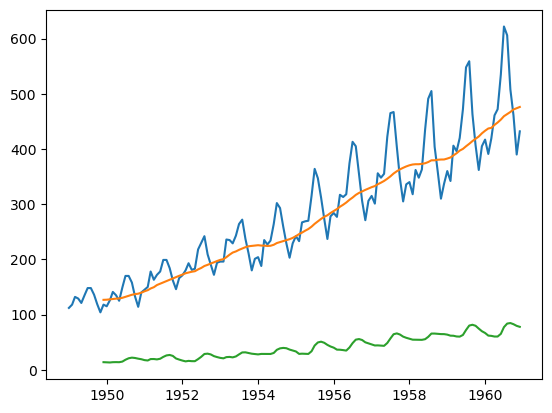

In [24]:
plt.plot(df,label='orgina')
plt.plot(mean,label='mean')
plt.plot(var,label='standard deviation')

In [25]:
log_df = np.log(df)

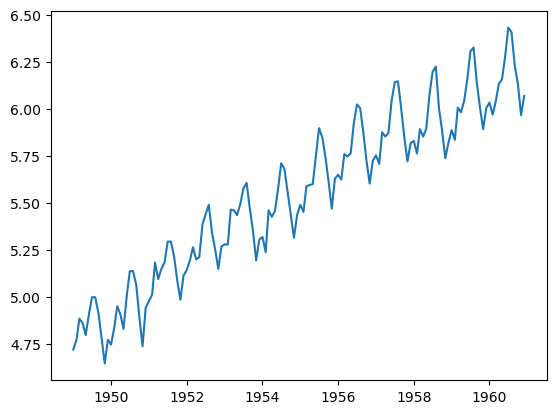

In [26]:
plt.plot(log_df)

## again Adfuller test

In [27]:
log_df.isna().sum()

#Passengers    0
dtype: int64

In [28]:
result = adfuller(log_df)

In [29]:
result[1]

np.float64(0.422366774770388)

**Data is still non stationary**

In [30]:
mean = log_df.rolling(window=12).mean()
var = log_df.rolling(window=12).std()

In [31]:
new_data = log_df-mean
new_data = new_data.dropna()
new_data

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
...,...
1960-08-01,0.282363
1960-09-01,0.098235
1960-10-01,-0.009230


In [32]:
mean = new_data.rolling(window=12).mean()
var = new_data.rolling(window=12).std()

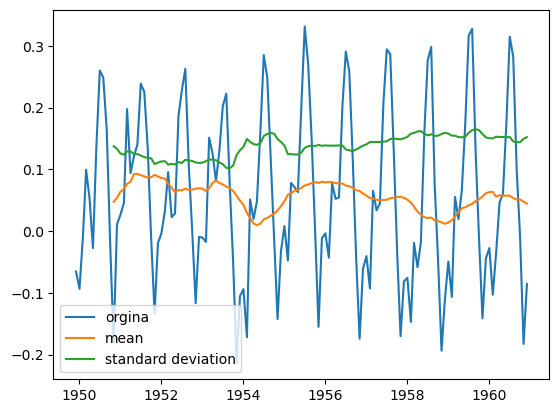

In [33]:
plt.plot(new_data,label='orgina')
plt.plot(mean,label='mean')
plt.plot(var,label='standard deviation')
plt.legend()

**Now data is stationary**

In [34]:
result = adfuller(new_data)
result[1]

np.float64(0.022234630001242456)

In [35]:
new_data.shape

(133, 1)

In [36]:
train = new_data.iloc[:106]['#Passengers']
test = new_data.iloc[106:]['#Passengers']

In [37]:
train

Month
1949-12-01   -0.065494
1950-01-01   -0.093449
1950-02-01   -0.007566
1950-03-01    0.099416
1950-04-01    0.052142
                ...   
1958-05-01   -0.018162
1958-06-01    0.160253
1958-07-01    0.276817
1958-08-01    0.298412
1958-09-01    0.075268
Name: #Passengers, Length: 106, dtype: float64

In [38]:
test

Month
1958-10-01   -0.045657
1958-11-01   -0.193762
1958-12-01   -0.110499
1959-01-01   -0.049241
1959-02-01   -0.106598
1959-03-01    0.055385
1959-04-01    0.019679
1959-05-01    0.066365
1959-06-01    0.176286
1959-07-01    0.316430
1959-08-01    0.327838
1959-09-01    0.128057
1959-10-01   -0.011315
1959-11-01   -0.141406
1959-12-01   -0.044481
1960-01-01   -0.027530
1960-02-01   -0.103067
1960-03-01   -0.036530
1960-04-01    0.046332
1960-05-01    0.060186
1960-06-01    0.175033
1960-07-01    0.315151
1960-08-01    0.282363
1960-09-01    0.098235
1960-10-01   -0.009230
1960-11-01   -0.182690
1960-12-01   -0.085789
Name: #Passengers, dtype: float64

In [39]:
from statsmodels.tsa.arima.model import ARIMA

## ARIMA 

- AutoRegressive Integrated Moving Average 

    **AutoRegressive (p)** - Control how many past values model should look 

    **Integrated (d)** - The number of times we subtract the previos value to make data stationary 
    
    **Moving Average (q)** - How many past forecast model errors the model should consider

In [40]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

<Figure size 1500x800 with 0 Axes>

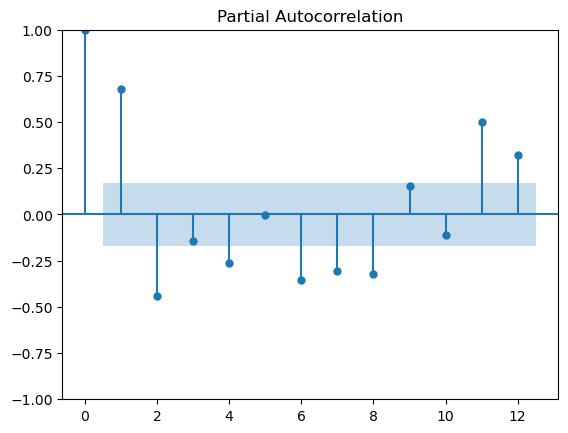

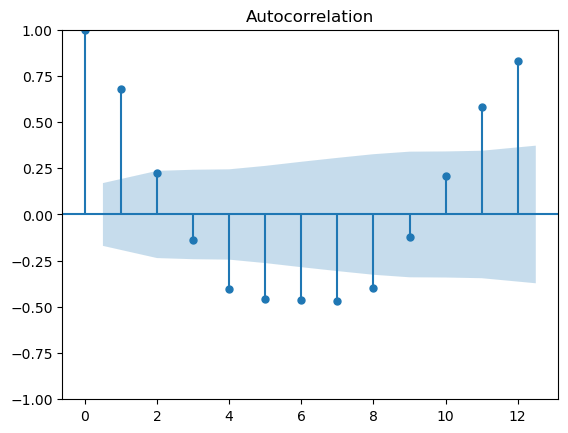

In [41]:

plt.figure(figsize = (15,8))
plot_pacf(new_data, lags=12)
#,lags=12
plot_acf(new_data,lags=12)
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


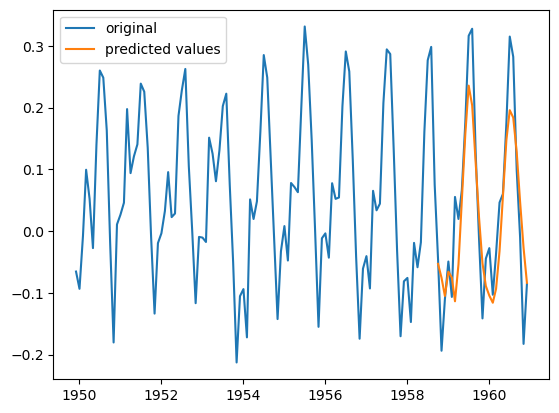

In [42]:
ar = ARIMA(train,order=(7,1,5))
ar_result = ar.fit()
new_data['predict_ar'] = ar_result.predict(start = len(train),end=len(train)+len(test)-1,dynamic=False)
plt.plot(new_data['#Passengers'],label='original')
plt.plot(new_data['predict_ar'],label='predicted values')
plt.legend()

In [44]:
from sklearn.metrics import *
import itertools
p = range(0,8)
d = range(1,2)
q = range(0,8)

pdq = list(itertools.product(p,d,q))
rmse = []
order1= []

for i in pdq:
    model = ARIMA(train,order=i)
    model = model.fit()
    pred = model.predict(start=len(train),end= len(train)+len(test)-1)
    error = np.sqrt(mean_squared_error(test,pred))
    order1.append(i)
    rmse.append(error)

results = pd.DataFrame(index=order1,data=rmse,columns=['RMSE'])

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be use

In [48]:
results.sort_values(by='RMSE',ascending=True)

,RMSE
"(5, 1, 7)",0.071453
"(7, 1, 7)",0.073296
"(6, 1, 7)",0.073702
"(4, 1, 7)",0.074271
"(7, 1, 5)",0.074995
...,...
"(0, 1, 2)",0.149744
"(0, 1, 1)",0.150150
"(2, 1, 0)",0.151556
"(3, 1, 0)",0.151889


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


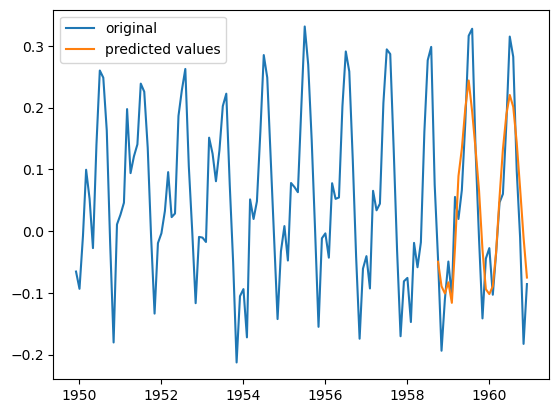

In [49]:
ar = ARIMA(train,order=(5,1,7))
ar_result = ar.fit()
new_data['predict_ar'] = ar_result.predict(start = len(train),end=len(train)+len(test)-1,dynamic=False)
plt.plot(new_data['#Passengers'],label='original')
plt.plot(new_data['predict_ar'],label='predicted values')
plt.legend()

In [52]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model1 = SARIMAX(train,order=(5,1,7),seasonal_order=(7,1,5,12))

model_sarima = model1.fit()

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<Axes: xlabel='Month'>

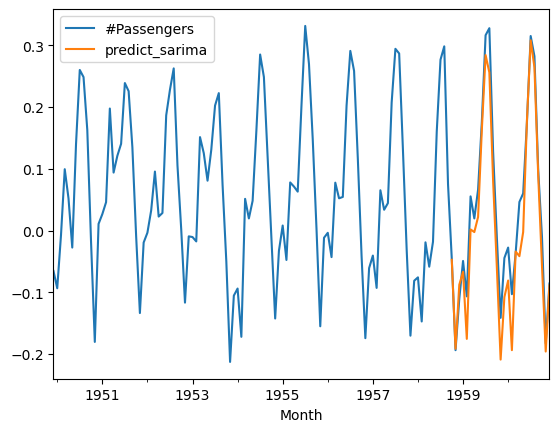

In [53]:
new_data['predict_sarima'] = model_sarima.predict(start=len(train),end=len(train)+len(test)-1)
new_data[['#Passengers','predict_sarima']].plot()